# CF-GNNExplainer Demo
This notebook demonstrates counterfactual explanations for a GNN classifier using the syn1 (BA-Shapes) dataset.

**Workflow:**
1. Import libraries
2. Load dataset + pre-trained GNN model
3. Fit CF-GNNExplainer for a chosen node
4. Inspect counterfactual possibilities (what edge perturbations flip the prediction)

## 1. Imports

In [1]:
import sys
import os
import pickle
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import dense_to_sparse

# Add src to path so we can import local modules
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from gcn import GCNSynthetic
from cf_explanation.cf_explainer import CFExplainer
from utils.utils import normalize_adj, get_neighbourhood

print('All imports OK')

All imports OK


## 2. Load Dataset

In [2]:
DATASET = 'syn1'   # change to 'syn4' or 'syn5' to try other datasets

data_path = f'data/gnn_explainer/{DATASET}.pickle'
with open(data_path, 'rb') as f:
    data = pickle.load(f)

adj       = torch.Tensor(data['adj']).squeeze()        # (N, N)
features  = torch.Tensor(data['feat']).squeeze()       # (N, F)
labels    = torch.tensor(data['labels']).squeeze()     # (N,)
idx_train = torch.tensor(data['train_idx'])
idx_test  = torch.tensor(data['test_idx'])

num_classes = len(labels.unique())
norm_adj    = normalize_adj(adj)

print(f'Dataset  : {DATASET}')
print(f'Nodes    : {adj.shape[0]}')
print(f'Features : {features.shape[1]}')
print(f'Classes  : {num_classes}  →  {labels.unique().tolist()}')
print(f'Train / Test : {len(idx_train)} / {len(idx_test)}')

Dataset  : syn1
Nodes    : 700
Features : 10
Classes  : 4  →  [0, 1, 2, 3]
Train / Test : 560 / 140


## 3. Load Pre-trained GNN Model

In [3]:
N_HID    = 20
N_OUT    = 20
DROPOUT  = 0.0

model = GCNSynthetic(
    nfeat   = features.shape[1],
    nhid    = N_HID,
    nout    = N_OUT,
    nclass  = num_classes,
    dropout = DROPOUT
)

model_path = f'models/gcn_3layer_{DATASET}.pt'
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model.eval()

# Forward pass over the full graph
with torch.no_grad():
    output     = model(features, norm_adj)          # (N, num_classes) log-softmax
    y_pred_all = torch.argmax(output, dim=1)        # (N,) predicted labels

acc_test = (y_pred_all[idx_test] == labels[idx_test]).float().mean().item()
print(f'Model loaded from {model_path}')
print(f'Test accuracy : {acc_test:.4f}')

# Class distribution in test set
print('\nPredicted class counts (test nodes):')
unique, counts = torch.unique(y_pred_all[idx_test], return_counts=True)
for c, n in zip(unique.tolist(), counts.tolist()):
    print(f'  class {c}: {n}')

Model loaded from models/gcn_3layer_syn1.pt
Test accuracy : 0.9786

Predicted class counts (test nodes):
  class 0: 61
  class 1: 30
  class 2: 30
  class 3: 19


## 4. Choose a Node to Explain

Pick any test-set node. We will ask: *"What is the minimum edge-perturbation that changes the GNN's prediction for this node?"*

The table below shows 30 candidate nodes. **Set `NODE_IDX` manually** to any node you want — prefer nodes predicted as a non-zero class, as class-0 nodes rarely yield CFs from edge deletions alone.

In [4]:
# Print candidate test nodes
print(f"{'node':>6}  {'true':>5}  {'pred':>5}")
print('-' * 22)
for n in idx_test[:30].tolist():
    marker = ' <--' if y_pred_all[n].item() != 0 else ''
    print(f"{n:6d}  {labels[n].item():5d}  {y_pred_all[n].item():5d}{marker}")

# ── Set NODE_IDX here ──────────────────────────────────────────────────────────
# Default: first non-class-0 test node (good starting point).
# Override manually: NODE_IDX = 123
non_zero_test = idx_test[(y_pred_all[idx_test] != 0)]
NODE_IDX = int(non_zero_test[0])
NODE_IDX = 464      
# ───────────────────────────────────────────────────────────────────────────────

print(f"\nChosen node : {NODE_IDX}")
print(f"True label  : {labels[NODE_IDX].item()}")
print(f"Predicted   : {y_pred_all[NODE_IDX].item()}")

  node   true   pred
----------------------
   563      2      2 <--
   415      1      1 <--
   605      1      1 <--
   320      1      1 <--
   232      0      0
   597      2      2 <--
   345      1      1 <--
   214      0      0
   367      2      2 <--
   206      0      0
   110      0      0
    15      0      0
   310      1      1 <--
   245      0      0
   496      1      1 <--
    13      0      0
   215      0      0
   298      0      0
   671      1      1 <--
   451      1      1 <--
   464      3      3 <--
   607      2      2 <--
   562      2      2 <--
   498      2      2 <--
   456      1      1 <--
   218      0      0
   688      2      2 <--
   151      0      0
   419      3      3 <--
   228      0      0

Chosen node : 464
True label  : 3
Predicted   : 3


## 5. Extract the k-hop Subgraph Around the Node

In [5]:
N_HOPS = 4   # same hop depth used in the paper

edge_index = dense_to_sparse(adj)[0]   # (2, E) edge index

sub_adj, sub_feat, sub_labels, node_dict = get_neighbourhood(
    node_idx  = NODE_IDX,
    edge_index = edge_index,
    n_hops    = N_HOPS,
    features  = features,
    labels    = labels
)

new_idx = node_dict[NODE_IDX]   # index of the target node inside the subgraph

print(f'Subgraph nodes : {sub_adj.shape[0]}')
print(f'Node re-index  : {NODE_IDX} → {new_idx} (inside subgraph)')
print(f'Sub-graph edges: {int(sub_adj.sum().item() / 2)}')

Subgraph nodes : 141
Node re-index  : 464 → 138 (inside subgraph)
Sub-graph edges: 526


## 6. Fit CF-GNNExplainer

The explainer learns a minimal perturbation matrix `P` (edge deletions by default) so that the perturbed adjacency causes the GNN to output a **different** class.

**Tuning tips if no CF is found:**
- Lower `BETA` (e.g. 0.1) — reduces the graph-distance penalty, allowing more edge changes
- Increase `NUM_EPOCHS` (e.g. 2000)
- Try a higher `LR` (e.g. 0.5)
- Switch to a different `NODE_IDX` in cell 4 (some nodes are structurally resistant)

In [6]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
BETA        = 0.5   
LR          = 0.1
N_MOMENTUM  = 0.9
NUM_EPOCHS  = 500
DEVICE      = 'cpu'
# ─────────────────────────────────────────────────────────────────────────────

explainer = CFExplainer(
    model         = model,
    sub_adj       = sub_adj,
    sub_feat      = sub_feat,
    n_hid         = N_HID,
    dropout       = DROPOUT,
    sub_labels    = sub_labels,
    y_pred_orig   = y_pred_all[NODE_IDX],
    num_classes   = num_classes,
    beta          = BETA,
    device        = DEVICE
)

print('Running CF-GNNExplainer ...')
cf_example = explainer.explain(
    cf_optimizer = 'SGD',
    node_idx     = NODE_IDX,
    new_idx      = new_idx,
    lr           = LR,
    n_momentum   = N_MOMENTUM,
    num_epochs   = NUM_EPOCHS
)

if cf_example:
    print('\nCounterfactual found!')
else:
    print('\nNo CF found. Try lowering BETA further, raising NUM_EPOCHS, or picking a different NODE_IDX.')

orig model requires_grad:  gc1.weight True
orig model requires_grad:  gc1.bias True
orig model requires_grad:  gc2.weight True
orig model requires_grad:  gc2.bias True
orig model requires_grad:  gc3.weight True
orig model requires_grad:  gc3.bias True
orig model requires_grad:  lin.weight True
orig model requires_grad:  lin.bias True
cf model requires_grad:  P_vec True
cf model requires_grad:  gc1.weight False
cf model requires_grad:  gc1.bias False
cf model requires_grad:  gc2.weight False
cf model requires_grad:  gc2.bias False
cf model requires_grad:  gc3.weight False
cf model requires_grad:  gc3.bias False
cf model requires_grad:  lin.weight False
cf model requires_grad:  lin.bias False
Running CF-GNNExplainer ...
Node idx: 464 New idx: 138 Epoch: 0001 loss: -0.8857 pred loss: -0.8857 graph loss: 0.0000
Output: tensor([-4.7634, -1.6965, -0.9270, -0.8857])
 Output nondiff: tensor([-3.5826, -1.7914, -1.6655, -0.4839])
 orig pred: 3, new pred: 3, new pred nondiff: 3
 
Node idx: 464 Ne

/Users/kazishahrukhomar/Documents/MISC/GMEL/CF-models/cf-gnnexplainer/src/cf_explanation/cf_explainer.py:99: UserWarning: torch.nn.utils.clip_grad_norm is now deprecated in favor of torch.nn.utils.clip_grad_norm_.
  clip_grad_norm(self.cf_model.parameters(), 2.0)


Node idx: 464 New idx: 138 Epoch: 0016 loss: 2.5000 pred loss: -5.5967 graph loss: 5.0000
Output: tensor([-13.3536,  -4.1573,  -0.0196,  -5.5967])
 Output nondiff: tensor([-4.6494, -0.2931, -2.3234, -1.9203])
 orig pred: 3, new pred: 2, new pred nondiff: 1
 
Node idx: 464 New idx: 138 Epoch: 0017 loss: 2.5000 pred loss: -5.4488 graph loss: 5.0000
Output: tensor([-13.0771,  -3.9960,  -0.0230,  -5.4488])
 Output nondiff: tensor([-4.6494, -0.2931, -2.3234, -1.9203])
 orig pred: 3, new pred: 2, new pred nondiff: 1
 
Node idx: 464 New idx: 138 Epoch: 0018 loss: 2.5000 pred loss: -5.3127 graph loss: 5.0000
Output: tensor([-12.8225,  -3.8486,  -0.0266,  -5.3127])
 Output nondiff: tensor([-4.6494, -0.2931, -2.3234, -1.9203])
 orig pred: 3, new pred: 2, new pred nondiff: 1
 
Node idx: 464 New idx: 138 Epoch: 0019 loss: 2.5000 pred loss: -5.1883 graph loss: 5.0000
Output: tensor([-12.5894,  -3.7147,  -0.0304,  -5.1883])
 Output nondiff: tensor([-4.6494, -0.2931, -2.3234, -1.9203])
 orig pred: 3,

## 7. Inspect the Counterfactual Result

In [7]:
if not cf_example:
    print('No CF example to inspect. See tuning tips in cell 6.')
else:
    (
        node_idx_r, new_idx_r,
        cf_adj,
        orig_sub_adj,
        y_pred_orig_r,
        y_pred_new_r,
        y_pred_new_actual,
        true_label,
        num_nodes,
        loss_total,
        loss_pred,
        loss_graph_dist
    ) = cf_example[-1]

    # cf_adj and orig_sub_adj are already numpy arrays
    if hasattr(cf_adj, 'numpy'):
        cf_adj = cf_adj.numpy()
    if hasattr(orig_sub_adj, 'numpy'):
        orig_sub_adj = orig_sub_adj.numpy()

    print('=== Counterfactual Summary ===')
    print(f'Node index          : {node_idx_r}')
    print(f'True label          : {true_label}')
    print(f'Original prediction : {y_pred_orig_r}')
    print(f'CF prediction       : {y_pred_new_actual}  ← flipped!')
    print()
    print(f'Total loss          : {loss_total:.4f}')
    print(f'  Prediction loss   : {loss_pred:.4f}')
    print(f'  Graph dist loss   : {loss_graph_dist:.4f}')

    diff    = cf_adj - orig_sub_adj
    added   = [(i, j) for (i, j) in zip(*np.where(diff > 0.5)) if i < j]
    removed = [(i, j) for (i, j) in zip(*np.where(diff < -0.5)) if i < j]

    print(f'\nEdges added   : {len(added)}')
    print(f'Edges removed : {len(removed)}')
    print(f'Total changes : {len(added) + len(removed)}')

    inv_dict = {v: k for k, v in node_dict.items()}
    if removed:
        print('\nRemoved edges (orig node ids):')
        for (i, j) in removed:
            print(f'  {inv_dict.get(i, i)} -- {inv_dict.get(j, j)}')
    if added:
        print('\nAdded edges (orig node ids):')
        for (i, j) in added:
            print(f'  {inv_dict.get(i, i)} -- {inv_dict.get(j, j)}')

=== Counterfactual Summary ===
Node index          : 464
True label          : 3
Original prediction : 3
CF prediction       : 2  ← flipped!

Total loss          : 1.5000
  Prediction loss   : -3.5126
  Graph dist loss   : 3.0000

Edges added   : 0
Edges removed : 3
Total changes : 3

Removed edges (orig node ids):
  460 -- 461
  461 -- 462
  461 -- 464


## 8. Visualize the Subgraph Before and After Perturbation

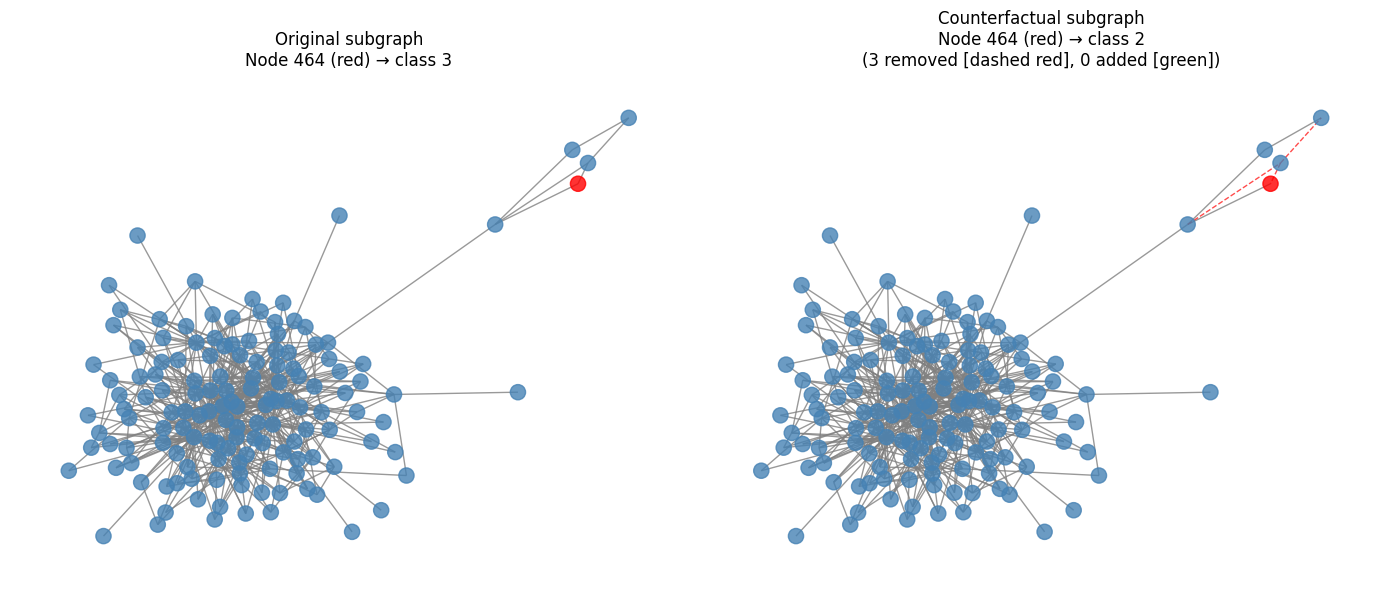

In [8]:
if cf_example:
    orig_np = orig_sub_adj if isinstance(orig_sub_adj, np.ndarray) else orig_sub_adj.numpy()
    cf_np   = cf_adj       if isinstance(cf_adj,       np.ndarray) else cf_adj.numpy()

    G_orig = nx.from_numpy_array(orig_np)
    G_cf   = nx.from_numpy_array(cf_np)

    node_colors_orig = ['red' if i == new_idx_r else 'steelblue' for i in G_orig.nodes]
    node_colors_cf   = ['red' if i == new_idx_r else 'steelblue' for i in G_cf.nodes]

    pos = nx.spring_layout(G_orig, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    nx.draw_networkx(
        G_orig, pos=pos, ax=axes[0],
        node_color=node_colors_orig,
        node_size=120, with_labels=False,
        edge_color='gray', alpha=0.8
    )
    axes[0].set_title(
        f'Original subgraph\nNode {node_idx_r} (red) → class {int(y_pred_orig_r)}',
        fontsize=12
    )
    axes[0].axis('off')

    edge_colors_cf = ['gray' if G_orig.has_edge(u, v) else 'green'
                      for (u, v) in G_cf.edges]
    removed_edges  = [(i, j) for (i, j) in G_orig.edges if not G_cf.has_edge(i, j)]

    nx.draw_networkx(
        G_cf, pos=pos, ax=axes[1],
        node_color=node_colors_cf,
        node_size=120, with_labels=False,
        edge_color=edge_colors_cf, alpha=0.8
    )
    nx.draw_networkx_edges(
        G_orig, pos=pos, ax=axes[1],
        edgelist=removed_edges,
        edge_color='red', style='dashed', alpha=0.7
    )
    axes[1].set_title(
        f'Counterfactual subgraph\nNode {node_idx_r} (red) → class {int(y_pred_new_actual)}\n'
        f'({len(removed)} removed [dashed red], {len(added)} added [green])',
        fontsize=12
    )
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

## 9. Scan Multiple Nodes — Quick CF Summary

Run the explainer over several test nodes to see which ones have counterfactuals and how many edge changes are needed.

In [ ]:
N_NODES_TO_TRY = 20    # set higher for a fuller picture (slower)
EPOCHS_QUICK   = 500
BETA_SCAN      = 0.1   # low beta for better recall

records = []

for node in idx_test[:N_NODES_TO_TRY].tolist():
    sub_a, sub_f, sub_l, n_dict = get_neighbourhood(
        node_idx   = node,
        edge_index = edge_index,
        n_hops     = N_HOPS,
        features   = features,
        labels     = labels
    )
    n_idx = n_dict[node]

    exp = CFExplainer(
        model         = model,
        sub_adj       = sub_a,
        sub_feat      = sub_f,
        n_hid         = N_HID,
        dropout       = DROPOUT,
        sub_labels    = sub_l,
        y_pred_orig   = y_pred_all[node],
        num_classes   = num_classes,
        beta          = BETA_SCAN,
        device        = DEVICE
    )

    result = exp.explain(
        cf_optimizer = 'SGD',
        node_idx     = node,
        new_idx      = n_idx,
        lr           = LR,
        n_momentum   = N_MOMENTUM,
        num_epochs   = EPOCHS_QUICK
    )

    if result:
        r = result[-1]
        cf_a = r[2] if isinstance(r[2], np.ndarray) else r[2].numpy()
        or_a = r[3] if isinstance(r[3], np.ndarray) else r[3].numpy()
        diff = cf_a - or_a
        n_changes = int(np.sum(np.abs(diff) > 0.5)) // 2
        records.append({
            'node'        : node,
            'true_label'  : int(r[7]),
            'pred_orig'   : int(r[4]),
            'pred_cf'     : int(r[6]),
            'edge_changes': n_changes,
            'loss_total'  : round(float(r[9]),  4),
            'loss_pred'   : round(float(r[10]), 4),
            'loss_graph'  : round(float(r[11]), 4),
        })
    else:
        records.append({
            'node'        : node,
            'true_label'  : int(labels[node].item()),
            'pred_orig'   : int(y_pred_all[node].item()),
            'pred_cf'     : None,
            'edge_changes': None,
            'loss_total'  : None,
            'loss_pred'   : None,
            'loss_graph'  : None,
        })

df = pd.DataFrame(records)
print(df.to_string(index=False))
print(f"\nCF found: {df['pred_cf'].notna().sum()} / {len(df)} nodes")